Example of how to parse the files and load data in dataframes.

In [1]:
#%pip install matplotlib

import os
import matplotlib.pyplot as plt
import matplotlib
import math
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [2]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

/Users/filipnordqvist/Documents/GitHub/Examensarbete/data


In [3]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [4]:
#%pip install pandas

import pandas as pd

# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)

noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [5]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_12
Loading test:  12_5
Loading test:  12_2
Loading test:  12_3
Loading test:  12_4
Loading test:  12_10
Loading test:  12_11
Loading test:  12_1
Loading test:  12_6
Loading test:  12_8
Loading test:  12_9
Loading test:  12_7
Loading test:  12_0
Loading test:  12_13
Loading test:  12_12
---------------------------------------------
Loading walking data for subject:  subject_15
---------------------------------------------
Loading walking data for subject:  subject_14
Loading test:  14_9
Loading test:  14_0
Loading test:  14_7
Loading test:  14_6
Loading test:  14_1
Loading test:  14_8
Loading test:  14_14
Loading test:  14_13
Loading test:  14_12
Loading test:  14_4
Loading test:  14_3
Loading test:  14_2
Loading test:  14_5
Loading test:  14_10
Loading test:  14_11
---------------------------------------------
Loading walking data for subject:  subject_13
Loading test:  13_11
Loading test:  13_10
L

In [6]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
#Events
print("Events: ", selection[0].events.head())
#Motion
print("Motion: ", selection[0].motion.head())
#Orientation
print("Orientation: ", selection[0].orientation.head())
#Positions
print("Positions: ", selection[0].positions.head())
#Steps
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  12_5
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0      961.0  241776.000023
Motion:     Unnamed: 0     ms    accelX    accelY    accelZ  accelWithGX  accelWithGY  \
0           0  301.0  0.438315 -0.063984 -0.070899    -0.022308     1.661179   
1           1  326.0  0.498090 -0.201496  0.016141    -0.035461     1.648026   
2           2  344.0  0.458053 -0.219058 -0.166888    -0.171860     1.747330   
3           3  366.0  0.212662 -0.051397 -0.305197    -0.256805     1.845428   
4           4  383.0  0.212662 -0.051397 -0.305197    -0.429092     1.931564   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0     9.639145      2.197900     3.448972      7.877995        16  
1     9.442932      5.656489     1.173263      5.241214        16  
2     9.349625      6.130341     0.611111      3.747971        16  
3     9.267059      7.771335     2.842233      4.861783        16  
4     9.143829 

In [7]:
#Saras code
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) * math.sin(dLat / 2) + \
        math.sin(dLon / 2) * math.sin(dLon / 2) * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

In [8]:
for i, test in enumerate(selection):
    print(f"Attributes of selection[{i}]:")
    print(vars(test))  # or print(test.__dict__)
    print("-" * 50)

Attributes of selection[0]:
{'filename': '12_5', 'events':    Unnamed: 0  signalStart  testStart        testEnd
0           0            0      961.0  241776.000023, 'motion':        Unnamed: 0        ms    accelX    accelY    accelZ  accelWithGX  \
0               0     301.0  0.438315 -0.063984 -0.070899    -0.022308   
1               1     326.0  0.498090 -0.201496  0.016141    -0.035461   
2               2     344.0  0.458053 -0.219058 -0.166888    -0.171860   
3               3     366.0  0.212662 -0.051397 -0.305197    -0.256805   
4               4     383.0  0.212662 -0.051397 -0.305197    -0.429092   
...           ...       ...       ...       ...       ...          ...   
13341       13341  241052.0  0.394181 -0.649407 -0.898338    -0.170654   
13342       13342  241070.0  0.453704 -0.624669 -1.077359    -0.170654   
13343       13343  241089.0  0.442678 -0.538984 -1.089510    -0.801163   
13344       13344  241105.0 -0.196482 -0.706071 -0.146003    -0.981827   
13345     

12_5
Total distance traveled for 10_0: 443.74 meters
    time_s  distance_m  delta_time_s  speed_mps
0    0.000    0.000000           NaN        NaN
1    1.483    3.168537         1.483   2.136573
2    2.707    3.992368         1.224   3.261738
3    3.704    1.953551         0.997   1.959429
4    4.707    1.675395         1.003   1.670384
..     ...         ...           ...        ...
95  95.710    1.308786         1.020   1.283124
96  96.704    1.185185         0.994   1.192339
97  97.698    2.096551         0.994   2.109206
98  98.688    0.912673         0.990   0.921892
99  99.702    1.055236         1.014   1.040667

[100 rows x 4 columns]


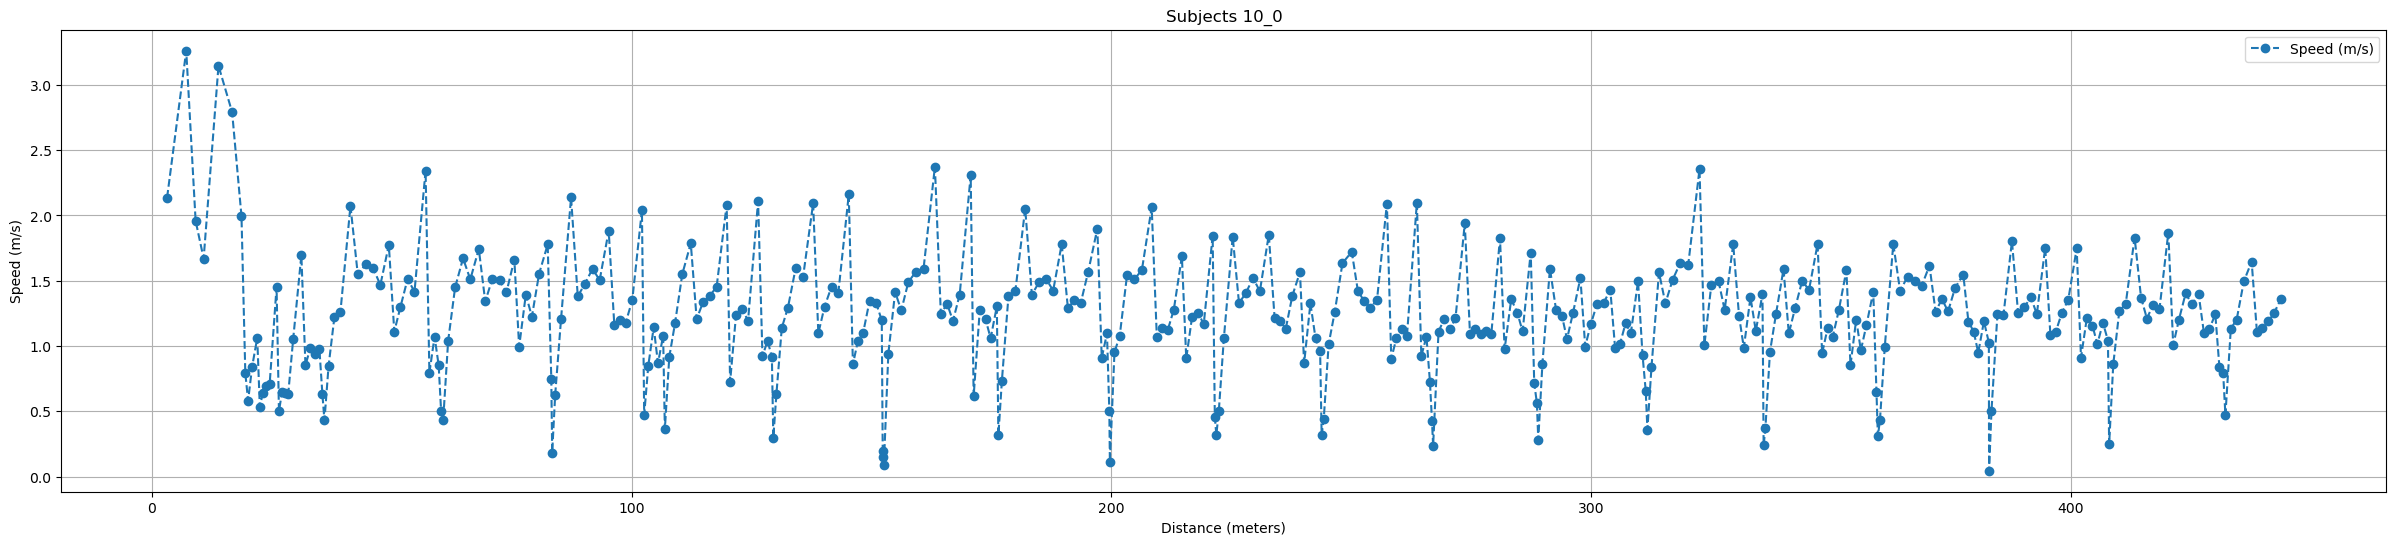

In [ ]:
import math

all_tests = []

for select in selection:
    all_tests.append(select.filename)
   
   

# Function to filter tests by subject name
def filter_tests_by_subject(selection, subject_name):
    return [test for test in selection if test.filename.startswith(subject_name)]

# Using the function to filter tests
subject_name = '10_0'  # Replace with the desired subject name
filtered_selection = filter_tests_by_subject(selection, subject_name)

# Proceed with the filtered selection
for test in filtered_selection:
    positions_data = test.positions.copy()  # Important to copy the data to avoid modifying the original

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points (protects against index errors)
    distances = [0] + [
        crowDist(positions_data.iloc[i-1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances

    # Total distance
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate time difference between measurement points
    positions_data['delta_time_s'] = positions_data['time_s'].diff()

    # Protect against division by small values or zero
    min_time_threshold = 0.1  # Minimum allowed time difference in seconds
    positions_data['delta_time_s'] = positions_data['delta_time_s'].clip(lower=min_time_threshold)

    # Calculate speed in m/s
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['delta_time_s']

    #Show the first 10 rows of data
    print(positions_data[['time_s', 'distance_m', 'delta_time_s', 'speed_mps']].head(100))

    # Plot for speed vs distance
    plt.figure(figsize=(30, 6))
    plt.plot(positions_data['distance_m'].cumsum(), positions_data['speed_mps'], marker='o', linestyle='--', label='Speed (m/s)')
    plt.xlabel('Distance (meters)')
    plt.ylabel('Speed (m/s)')
    plt.title(f"Subjects {test.filename}")
    plt.legend()
    plt.grid()
    plt.show()

In [10]:
#%pip install tensorflow

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

positions_data_full = positions_data.copy()

# Select relevant features and remove missing values
positions_data = positions_data[['latitude', 'longitude', 'altitude', 'speed_mps']].dropna()

# Scale data to the range [0, 1] for better training performance
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(positions_data.values)

# Create time series sequences for GRU input
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, :])
    return np.array(X), np.array(y)

time_step = 10  # Number of previous time steps to consider
X, y = create_dataset(scaled_data, time_step)

# Reshape input for GRU: (samples, time_steps, features)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

# Build GRU model with two stacked layers
model = Sequential()
model.add(GRU(units=360, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(GRU(units=360))
model.add(Dense(units=4))  # Output: latitude, longitude, altitude, speed
#model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error') #MSE
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_error') #MAE

# Train the model
model.fit(X, y, epochs=50, batch_size=32)

# Predict 6MWT
prediction_seconds = 360

# Use the last known sequence as input seed
input_seq = scaled_data[-time_step:].reshape(1, time_step, scaled_data.shape[1])
predictions = []

# Iteratively generate predictions and feed them back into the model
for _ in range(prediction_seconds):
    pred = model.predict(input_seq, verbose=0)[0]
    predictions.append(pred)
    new_input = np.append(input_seq[0, 1:, :], [pred], axis=0)
    input_seq = new_input.reshape(1, time_step, scaled_data.shape[1])

# Convert predictions back to original scale
predictions = np.array(predictions)
inverted_predictions = scaler.inverse_transform(predictions)

# Extract speed column (index 3) and compute cumulative distance
delta_t = 1  # Assuming 1 second between each sample
predicted_speeds = inverted_predictions[:, 3]
predicted_distances = np.cumsum(predicted_speeds * delta_t)

Epoch 1/50


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.1851
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0360
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0286
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0306
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0292
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0291
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0287
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.0269
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.0256
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0241
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0235 
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.0216
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0300
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.0264
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0247
Epoch 16/50


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0212 - val_loss: 0.0231
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0186 - val_loss: 0.0190
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 0.0196 - val_loss: 0.0193
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - loss: 0.0209 - val_loss: 0.0189
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 0.0216 - val_loss: 0.0233
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - loss: 0.0201 - val_loss: 0.0207
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0207 - val_loss: 0.0273
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - loss: 0.0227 - val_loss: 0.0195
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0230 - val_loss: 0.0247
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - loss: 0.0197 - val_loss: 0.0200
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - loss: 0.0186 - val_loss: 0.0203
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - 

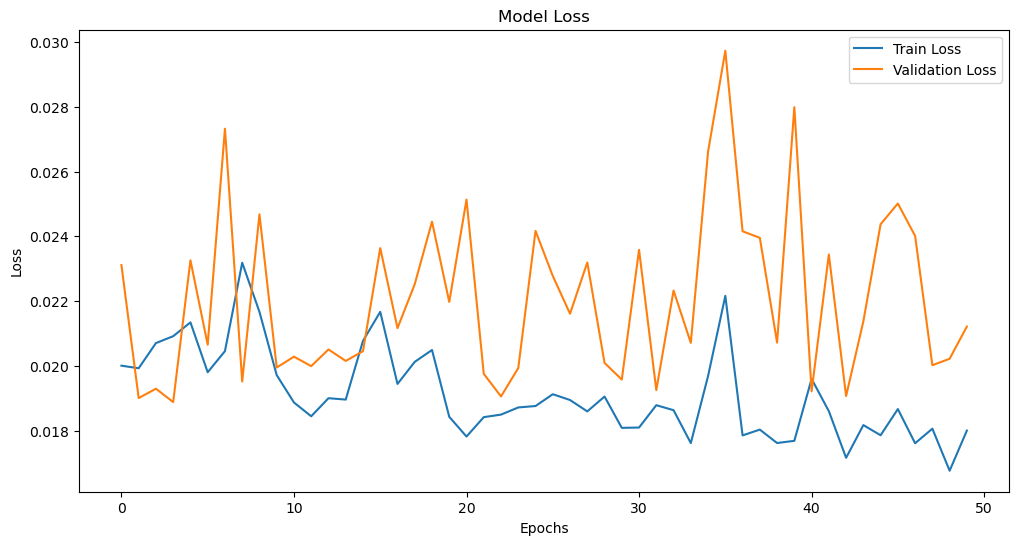

In [11]:
# Train the model and store the training history
history = model.fit(X, y, validation_split=0.2, epochs=50, batch_size=32)

# Visualize the training process
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



# Loopa alla subject och gör ett dataset att visa:

In [12]:
print("Predicted distance: ", predicted_distances[-1])
print("Actual distance: ", total_distance)
print("Difference: ", predicted_distances[-1] - total_distance)


Predicted distance:  -605.7803
Actual distance:  466.8727076504788
Difference:  -1072.6529810879788


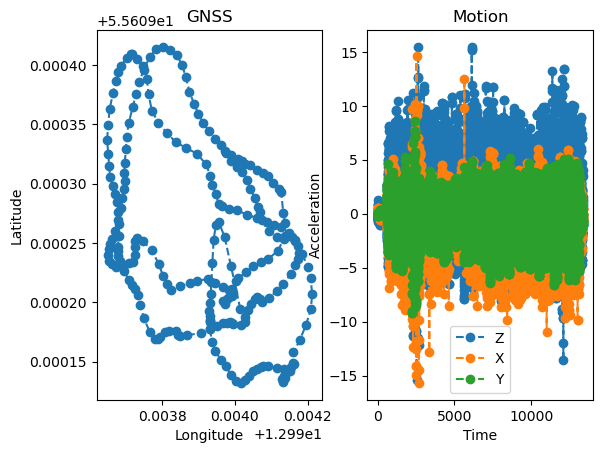

In [13]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()
